In [152]:
import itertools
import mujoco
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.spatial.transform import Rotation as R

In [153]:
class JumpSimulator:
    def __init__(self, horizontal_velocity, vertical_velocity, incident_angle, angular_velocity):
        self.hv = horizontal_velocity
        self.vv = vertical_velocity
        self.ia = incident_angle
        self.av = angular_velocity

        self.num_steps = 600
        self.positions = []
        self.num_contacts = []
        self.saved_qpos = []
        self.max_height_after = 0
        self.max_height_after_idx = None
        self.first_contact = None
        self.first_contact_end = None
        self.second_contact = None
        in_contact = False

        self._setup_sim()

    def _setup_sim(self):
        half_rod_length = 0.9144
        xml = f"""
        <mujoco>
            <option gravity="0 0 -9.81"/>
            <worldbody>
                <camera name="sideview" pos="2 0 0.5" euler="0 90 90"/>
                <geom name="ground" type="plane" size="2 2 0.1" pos="0 0 0" rgba="0 0.6 0 1" friction="1 0 0"/>
                <body name="rodd" pos="0 -0.5 1">
                    <freejoint/>
                    <geom name="rod" type="cylinder" pos="0 0 0" size="0.001 {half_rod_length}" rgba="1 1 1 1" solref="0.001 0" solimp="1 1 1 1 1" friction="1 0 0" density="1000"/>
                </body>
            </worldbody>
        </mujoco>
        """
        self.model = mujoco.MjModel.from_xml_string(xml)
        self.data = mujoco.MjData(self.model)

        self.data.qpos[0:3] = [0, -0.5, 0.01 + np.cos(self.ia)*half_rod_length]
        self.data.qpos[3:7] = [np.cos(self.ia / 2), np.sin(self.ia / 2), 0, 0]
        self.data.qvel[0:6] = [0, self.hv, self.vv, self.av, 0, 0]

        self.rod_geom_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_GEOM, "rod")

    def run(self):
        for _ in range(self.num_steps):
            mujoco.mj_step(self.model, self.data)
            self.positions.append(self.data.xipos[1].copy())
            self.num_contacts.append(self.data.ncon)
            self.saved_qpos.append(self.data.qpos.copy())

        self.positions = np.array(self.positions)
        self.saved_qpos = np.array(self.saved_qpos)
        self._detect_contacts()
        self._compute_max_height()

    def _detect_contacts(self):
        self.first_contact = None
        self.first_contact_end = None
        self.second_contact = None
        in_contact = False
        for i, n in enumerate(self.num_contacts):
            if n > 0 and not in_contact:
                if self.first_contact is None:
                    self.first_contact = i
                elif self.first_contact_end is not None and self.second_contact is None:
                    self.second_contact = i
                in_contact = True
            if n == 0 and in_contact:
                if self.first_contact_end is None:
                    self.first_contact_end = i
                in_contact = False

    def _compute_max_height(self):
        # Compute max height between first and second collision
        if self.first_contact_end is not None and self.second_contact is not None:
            z_between = self.positions[self.first_contact_end:self.second_contact, 2]
            if len(z_between) > 0:
                self.max_height_after = np.max(z_between)
                self.max_height_after_idx = np.argmax(z_between) + self.first_contact_end
        else:
            self.max_height_after = 0
            self.max_height_after_idx = None

    def get_max_height(self):
        return self.max_height_after

    def print_summary(self):
        if self.first_contact is not None and self.first_contact_end is not None:
            duration = self.first_contact_end - self.first_contact
            print(f"First collision lasts {duration} steps")
        elif self.first_contact is not None:
            print(f"First collision starts at step {self.first_contact} and lasts until the end of the simulation")
        else:
            print("No collision detected in the simulation")

        if self.max_height_after_idx is not None:
            print(f"Max height after collision: {self.max_height_after:.4f} m at step {self.max_height_after_idx}")
        else:
            print("No valid height found after collision.")

    def analyze_orientation_at_events(self):
        if self.first_contact is None or self.max_height_after_idx is None:
            return

        for step, label in [(self.first_contact, "contact"), (self.max_height_after_idx, "peak")]:
            quat = self.saved_qpos[step, 3:7]
            quat_xyzw = [quat[1], quat[2], quat[3], quat[0]]
            rot_matrix = R.from_quat(quat_xyzw).as_matrix()
            axis_yz = rot_matrix[1:, 2]
            angle_rad = np.arctan2(axis_yz[1], axis_yz[0])
            angle_deg = np.degrees(angle_rad)
            print(f"Angle at {label} (step {step}): {angle_deg:.2f} degrees")

    def summarize_parameters(self):
        print("Simulation Parameters:")
        print(f"  Horizontal Velocity: {self.hv:.2f} m/s")
        print(f"  Vertical Velocity: {self.vv:.2f} m/s")
        print(f"  Incident Angle: {np.degrees(self.ia):.2f} degrees")
        print(f"  Angular Velocity: {self.av:.2f} rad/s")

    def animate_jump(self):
        frames = []
        num_frames = min(200, len(self.saved_qpos))
    
        renderer = mujoco.Renderer(self.model)
        data_render = mujoco.MjData(self.model)
        for i in range(num_frames):
            data_render.qpos[:] = self.saved_qpos[i]
            # If you also saved velocities:
            # data_render.qvel[:] = self.saved_qvel[i]
            mujoco.mj_forward(self.model, data_render)
            renderer.update_scene(data_render, camera="sideview")
            frame = renderer.render()
            frames.append(frame)
    
        fig, ax = plt.subplots()
        im = ax.imshow(frames[0])
        ax.axis('off')
    
        def update(i):
            im.set_data(frames[i])
            return [im]
    
        ani = FuncAnimation(fig, update, frames=num_frames, interval=20, blit=True)
        plt.close(fig)
        display(HTML(ani.to_jshtml()))

In [154]:
def flexible_graph(iv1, iv1_min, iv1_max, iv1_step, iv2, iv2_min, iv2_max, iv2_step, sv1, sv1_default, sv2, sv2_default):
    # Set up the parameter names
    param_names = ['hv', 'vv', 'ia', 'av']
    static_vars = {sv1: sv1_default, sv2: sv2_default}

    # Create the ranges for the swept variables
    iv1_range = np.arange(iv1_min, iv1_max, iv1_step)
    iv2_range = np.arange(iv2_min, iv2_max, iv2_step)

    plt.figure()
    for iv2_value in iv2_range:
        max_heights = []
        iv1s = []
        for iv1_value in iv1_range:
            # Set up all parameters for this run
            params = static_vars.copy()
            params[iv1] = iv1_value
            params[iv2] = iv2_value

            sim = JumpSimulator(
                params.get('hv', 0),
                params.get('vv', 0),
                params.get('ia', 0),
                params.get('av', 0)
            )

            sim.run()
            max_height_after = sim.get_max_height()
            iv1s.append(iv1_value)
            max_heights.append(max_height_after)

        # Make a nice label for the legend
        if iv2 == 'ia':
            label = f"{iv2}={np.degrees(iv2_value):.1f}°"
        else:
            label = f"{iv2}={iv2_value:.2f}"

        plt.plot(iv1s, max_heights, marker='o', markersize=3, label=label)

    plt.xlabel(iv1)
    plt.ylabel('Max Jump Height (m)')
    plt.title(f'Max Jump Height vs {iv1} (for different {iv2})')
    plt.grid(True)
    plt.legend()
    plt.gcf().text(
        0.14, 0.665,  # Adjust position as needed
        f"Fixed ia={np.degrees(static_vars.get('ia', 0)):.2f}°\nFixed av={static_vars.get('av', 0):.2f} rad/s",
        fontsize=10, va='top'
    )
    plt.show()

In [155]:
def flexible_heatmap(
    axis1, axis1_range,
    axis2, axis2_range,
    fixed1, fixed1_value,
    fixed2, fixed2_value
):
    """
    Plots a heatmap of max jump height for any two swept variables.
    axis1, axis2: names of variables to sweep ('hv', 'vv', 'ia', 'av')
    axis1_range, axis2_range: arrays of values for those variables
    fixed1, fixed2: names of fixed variables
    fixed1_value, fixed2_value: values for fixed variables
    """
    param_names = ['hv', 'vv', 'ia', 'av']
    # Convert to radians if sweeping over 'ia'
    if axis1 == 'ia':
        axis1_vals = np.radians(axis1_range)
    else:
        axis1_vals = axis1_range
    if axis2 == 'ia':
        axis2_vals = np.radians(axis2_range)
    else:
        axis2_vals = axis2_range

    heights = np.zeros((len(axis2_vals), len(axis1_vals)))

    for i, val2 in enumerate(axis2_vals):
        for j, val1 in enumerate(axis1_vals):
            params = {fixed1: fixed1_value, fixed2: fixed2_value}
            params[axis1] = val1
            params[axis2] = val2
            sim = JumpSimulator(
                params.get('hv', 0),
                params.get('vv', 0),
                params.get('ia', 0),
                params.get('av', 0)
            )
            sim.run()
            heights[i, j] = sim.get_max_height()

    # For labeling, convert radians back to degrees if needed
    axis1_label = f"{axis1} (deg)" if axis1 == 'ia' else axis1
    axis2_label = f"{axis2} (deg)" if axis2 == 'ia' else axis2
    axis1_ticks = np.degrees(axis1_vals) if axis1 == 'ia' else axis1_vals
    axis2_ticks = np.degrees(axis2_vals) if axis2 == 'ia' else axis2_vals

    plt.figure(figsize=(10, 6))
    extent = [axis1_ticks[0], axis1_ticks[-1], axis2_ticks[0], axis2_ticks[-1]]
    cmap = plt.get_cmap('Reds').copy()
    cmap.set_bad(color='gray')
    masked_heights = np.ma.masked_invalid(heights)
    plt.imshow(masked_heights, extent=extent, origin='lower', aspect='auto', cmap=cmap)
    plt.colorbar(label='Max Jump Height (m)')
    plt.xlabel(axis1_label)
    plt.ylabel(axis2_label)
    plt.title(f"Heatmap of Max Jump Height\nFixed {fixed1}={fixed1_value}, {fixed2}={fixed2_value}")
    plt.grid(False)
    plt.show()

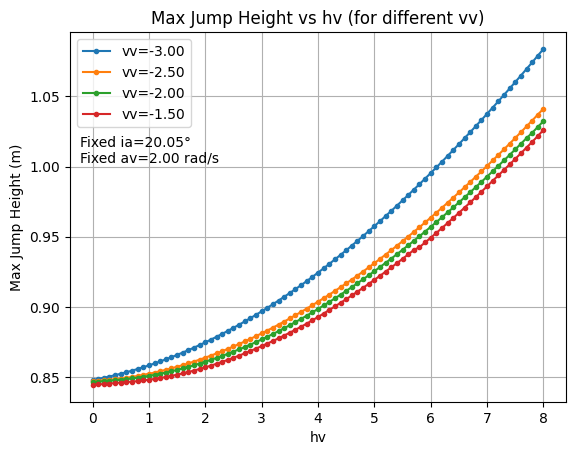

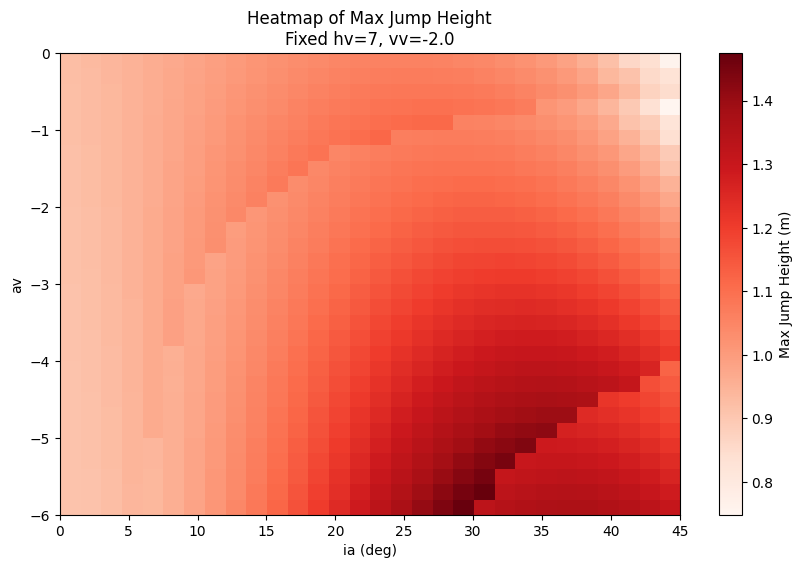

In [156]:
flexible_graph('hv', 0, 8.01, 0.1, 'vv', -3, -1.4, 0.5, 'ia', 0.35, 'av', 2)

flexible_heatmap(
    axis1='ia', axis1_range=np.linspace(0, 45, 30),
    axis2='av', axis2_range=np.linspace(-6, 0, 30),
    fixed1='hv', fixed1_value=7,
    fixed2='vv', fixed2_value=-2.0
)